## WordClouds

In [ ]:
### Chargement des données processées

import pandas as pd
main_data = "data_final_streamlit"
df = pd.read_csv(f'{main_data}/40k_final_process.csv', sep=',', header=0, index_col=0) # chargement des données après preprocessing final

[nltk_data] Downloading package punkt to /home/robin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/robin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/robin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/robin/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


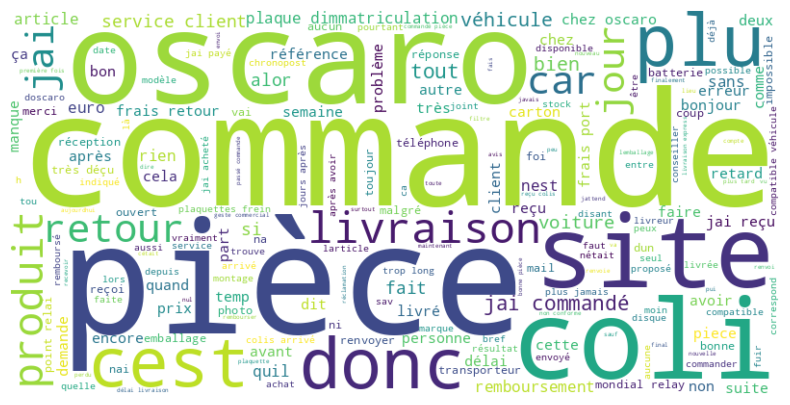

In [5]:
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Télécharger les ressources nécessaires (à faire une seule fois)
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('punkt_tab')

# Exemple de texte
#text = " ".join(df['commentaire'])
text = " ".join(df[df['note'] == 1]['commentaire'].to_list())
text_to_emb = " ".join(df['commentaire'].to_list())
# 1️⃣ Lowercase
text = text.lower()
text_to_emb = text_to_emb.lower()
# 2️⃣ Suppression ponctuation et chiffres
text = re.sub(r"[^a-zàâäéèêëîïôöùûüç\s]", "", text)
text_to_emb = re.sub(r"[^a-zàâäéèêëîïôöùûüç\s]", "", text_to_emb)
# 3️⃣ Tokenisation
tokens = word_tokenize(text)
tokens_to_emb = word_tokenize(text_to_emb)
# 4️⃣ Suppression des stopwords
stop_words = set(stopwords.words("french"))
tokens = [word for word in tokens if word not in stop_words]
tokens_to_emb = [word for word in tokens_to_emb if word not in stop_words]
# 5️⃣ Lemmatisation
lemmatizer = WordNetLemmatizer()
tokens = [lemmatizer.lemmatize(word) for word in tokens]
tokens_to_emb = [lemmatizer.lemmatize(word) for word in tokens_to_emb]
# 6️⃣ Rejointure
processed_text = " ".join(tokens)

# 7️⃣ Wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(processed_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

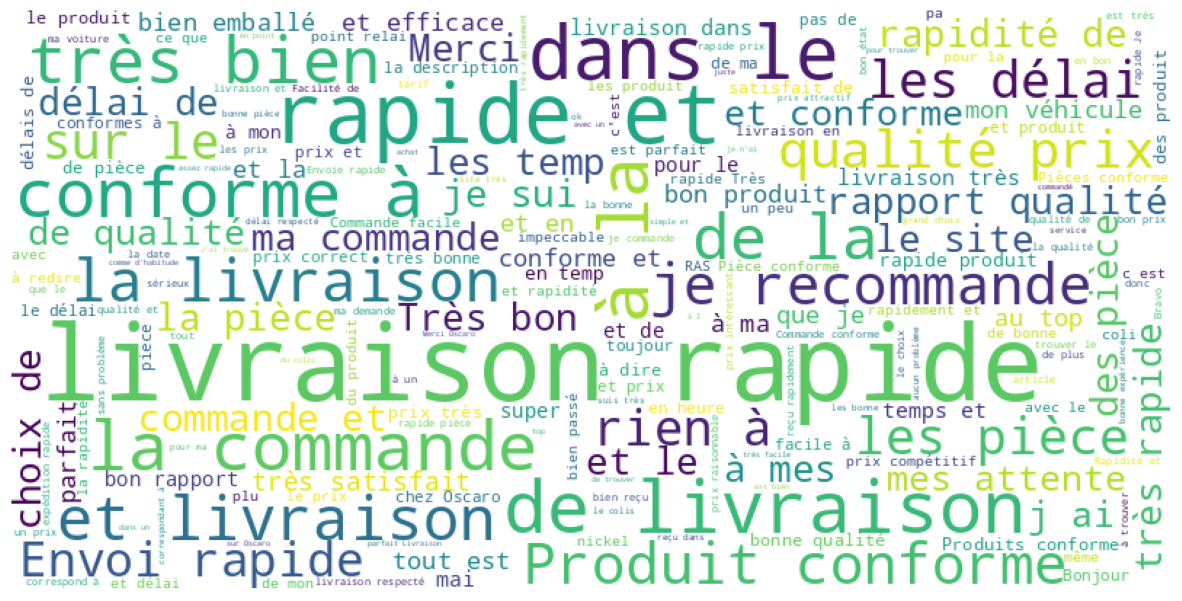

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud



corpus = df['commentaire']
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
features = vectorizer.get_feature_names_out()

text = " ".join(df[df['note'] == 5]['commentaire'].to_list())
#text = " ".join(df['commentaire'].to_list())
# 2️⃣ Générer le word cloud
wc = WordCloud(width=800, height=400, background_color="white")
wc.generate(text)


plt.figure(figsize=(15,10))

plt.imshow(wc)
plt.axis("off")
plt.show()